# Wordcloud Analysis by Historical Era

This notebook generates wordclouds for each historical era based on Wikipedia content of influential people born in those eras.

## 1. Load Required Libraries and Data

Import necessary libraries and load the network with sentiment attributes.

In [1]:
# Import required libraries
import urllib.request
import networkx as nx
import json
import re
import string
import matplotlib.pyplot as plt
import numpy as np
from wordcloud import WordCloud
from collections import defaultdict
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the network with sentiment attributes
file_path = '/Volumes/MASTER/Year1/Social_graphs/project/celebrities_with_sentiment.graphml'

try:
    network = nx.read_graphml(file_path)
    print(f"✓ Network loaded successfully!")
    print(f"  Nodes: {network.number_of_nodes()}")
    print(f"  Edges: {network.number_of_edges()}")
except Exception as e:
    print(f"✗ Error loading network: {str(e)}")
    network = None

✓ Network loaded successfully!
  Nodes: 3422
  Edges: 17581


## 2. Define Historical Eras

Define function to categorize people into historical eras based on their birth year.

In [3]:
def get_era(birth_year):
    """Determine which era a birth year belongs to"""
    if birth_year is None:
        return 'Unknown'
    
    try:
        year = int(birth_year)
    except (ValueError, TypeError):
        return 'Unknown'
    
    if year < 30:
        return 'Before Christ (< 30)'
    elif 30 <= year < 476:
        return 'Classical Era (30-476)'
    elif 476 <= year < 1450:
        return 'Middle Ages (476-1450)'
    elif 1450 <= year < 1760:
        return 'Early Modern (1450-1760)'
    elif 1760 <= year < 1840:
        return 'Industrial Era (1760-1840)'
    elif 1840 <= year < 1945:
        return 'Wartime (1840-1945)'
    elif 1945 <= year <= 2025:
        return 'Post-War (1945-2025)'
    else:
        return 'Unknown'

print("Era classification function defined!")

Era classification function defined!


## 3. Filter Network by Era

Group all people in the network by their birth era.

In [4]:
# Group people by era
era_groups = defaultdict(list)

for node in network.nodes():
    birth_year = network.nodes[node].get('birthyear', None)
    era = get_era(birth_year)
    era_groups[era].append(node)

# Display summary
print("People grouped by era:")
print("=" * 60)

# Define era order for display
era_order = [
    'Before Christ (< 30)',
    'Classical Era (30-476)',
    'Middle Ages (476-1450)',
    'Early Modern (1450-1760)',
    'Industrial Era (1760-1840)',
    'Wartime (1840-1945)',
    'Post-War (1945-2025)',
    'Unknown'
]

for era in era_order:
    if era in era_groups:
        print(f"{era:30s}: {len(era_groups[era]):5d} people")
        # Show first 3 people from this era
        for person in era_groups[era][:3]:
            name = network.nodes[person].get('Name', person)
            birth_year = network.nodes[person].get('birthyear', 'N/A')
            print(f"  - {name} (born {birth_year})")
        if len(era_groups[era]) > 3:
            print(f"  ... and {len(era_groups[era]) - 3} more")
        print()

People grouped by era:
Before Christ (< 30)          :    69 people
  - Alcibiades (born -450.0)
  - Pope Anacletus (born 1.0)
  - Miltiades the Younger (born -550.0)
  ... and 66 more

Classical Era (30-476)        :    56 people
  - Pope Julius I (born 300.0)
  - Aulus Gellius (born 130.0)
  - Pope Anastasius II (born 450.0)
  ... and 53 more

Middle Ages (476-1450)        :   223 people
  - Pope Eugene IV (born 1383.0)
  - Athelstan of England (born 895.0)
  - Edward the Martyr (born 962.0)
  ... and 220 more

Early Modern (1450-1760)      :   299 people
  - Thomas Arne (born 1710.0)
  - Molière (born 1622.0)
  - Osman II (born 1604.0)
  ... and 296 more

Industrial Era (1760-1840)    :   232 people
  - Isma'il Pasha (born 1830.0)
  - Francis Galton (born 1822.0)
  - John Henry Cardinal Newman (born 1801.0)
  ... and 229 more

Wartime (1840-1945)           :  1285 people
  - Adolfo Pérez Esquivel (born 1931.0)
  - Gustave Caillebotte (born 1848.0)
  - Pierre-Gilles de Gennes (born 1

## 4. Fetch Wikipedia Content by Era

Define helper functions and fetch Wikipedia content for each era.

In [5]:
def clean_tokenize_lemmatize_nltk(text):
    """
    Clean, tokenize, and lemmatize text from Wikipedia content.
    
    Args:
        text: Raw text content
    
    Returns:
        list: List of cleaned and lemmatized tokens
    """
    # If input is JSON string, extract the wikitext content
    if isinstance(text, str) and text.strip().startswith('{'):
        try:
            data = json.loads(text)
            pages = data.get('query', {}).get('pages', {})
            page_content = next(iter(pages.values()))
            text = page_content.get('revisions', [{}])[0].get('slots', {}).get('main', {}).get('*', '')
        except (json.JSONDecodeError, KeyError, StopIteration):
            pass
    
    # Remove MediaWiki markup
    text = re.sub(r'\{\{[^}]*\}\}', '', text)
    text = re.sub(r'\[\[(?:[^|\]]*\|)?([^\]]+)\]\]', r'\1', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'<ref[^>]*>.*?</ref>', '', text, flags=re.DOTALL)
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'\[\[File:.*?\]\]|\[\[Image:.*?\]\]', '', text, flags=re.IGNORECASE)
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove punctuation
    text = text.translate(str.maketrans(string.punctuation, ' ' * len(string.punctuation)))
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords and short tokens
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words and len(token) > 2]
    
    # Lemmatize
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    
    # Remove non-alphabetic tokens
    tokens = [token for token in tokens if token.isalpha()]
    
    # Remove common wiki artifacts
    tokens = [token for token in tokens if token not in {
        'nbsp', 'also', 'align', 'center', 'nugent', 'ncategory', 
        'text', 'nin', 'parser', 'output', 'hlist', 'html', 'navbox', 
        'font', 'sidebar', 'infobox'
    }]
    
    return tokens

print("Text cleaning function defined!")

Text cleaning function defined!


In [6]:
def get_combined_content(people_list, network):
    """
    Fetch Wikipedia content for a list of people and combine it.
    
    Args:
        people_list: List of node IDs
        network: NetworkX graph
        
    Returns:
        str: Combined Wikipedia content (plain text)
    """
    combined_content = []
    errors = 0
    
    for person in people_list:
        try:
            wiki_link = network.nodes[person].get('Link', '')
            if wiki_link:
                # Extract page title from URL
                page_title = wiki_link.split('/wiki/')[-1]
                
                # Use Wikipedia API to get clean plain text content
                api_url = f"https://en.wikipedia.org/w/api.php?action=query&format=json&titles={page_title}&prop=extracts&explaintext=true"
                
                req = urllib.request.Request(api_url, headers={'User-Agent': "Magic Browser"}) 
                con = urllib.request.urlopen(req)
                response = con.read().decode('utf-8')
                data = json.loads(response)
                
                # Extract the text content
                pages = data['query']['pages']
                for page_id in pages:
                    if 'extract' in pages[page_id]:
                        content = pages[page_id]['extract']
                        combined_content.append(content)
                        break
                        
        except Exception as e:
            errors += 1
            continue
    
    print(f"  Fetched content for {len(combined_content)}/{len(people_list)} people ({errors} errors)")
    return ' '.join(combined_content)

print("Content fetching function defined!")

Content fetching function defined!


## 5. Generate Wordclouds for Each Era

Generate and display wordclouds showing the most common words for each historical period.

Processing 7 eras with sufficient data...

Processing Era 1/7: Post-War (1945-2025)
Number of people: 1258
  Fetched content for 1136/1258 people (122 errors)
✓ Wordcloud generated successfully!
  Total tokens: 1279156
  Unique words: 56772

Processing Era 2/7: Wartime (1840-1945)
Number of people: 1285
  Fetched content for 1169/1285 people (116 errors)
✓ Wordcloud generated successfully!
  Total tokens: 2105182
  Unique words: 86553

Processing Era 3/7: Industrial Era (1760-1840)
Number of people: 232
  Fetched content for 204/232 people (28 errors)
✓ Wordcloud generated successfully!
  Total tokens: 385435
  Unique words: 34240

Processing Era 4/7: Middle Ages (476-1450)
Number of people: 223
  Fetched content for 213/223 people (8 errors)
✓ Wordcloud generated successfully!
  Total tokens: 247282
  Unique words: 24359

Processing Era 5/7: Early Modern (1450-1760)
Number of people: 299
  Fetched content for 278/299 people (21 errors)
✓ Wordcloud generated successfully!
  Total token

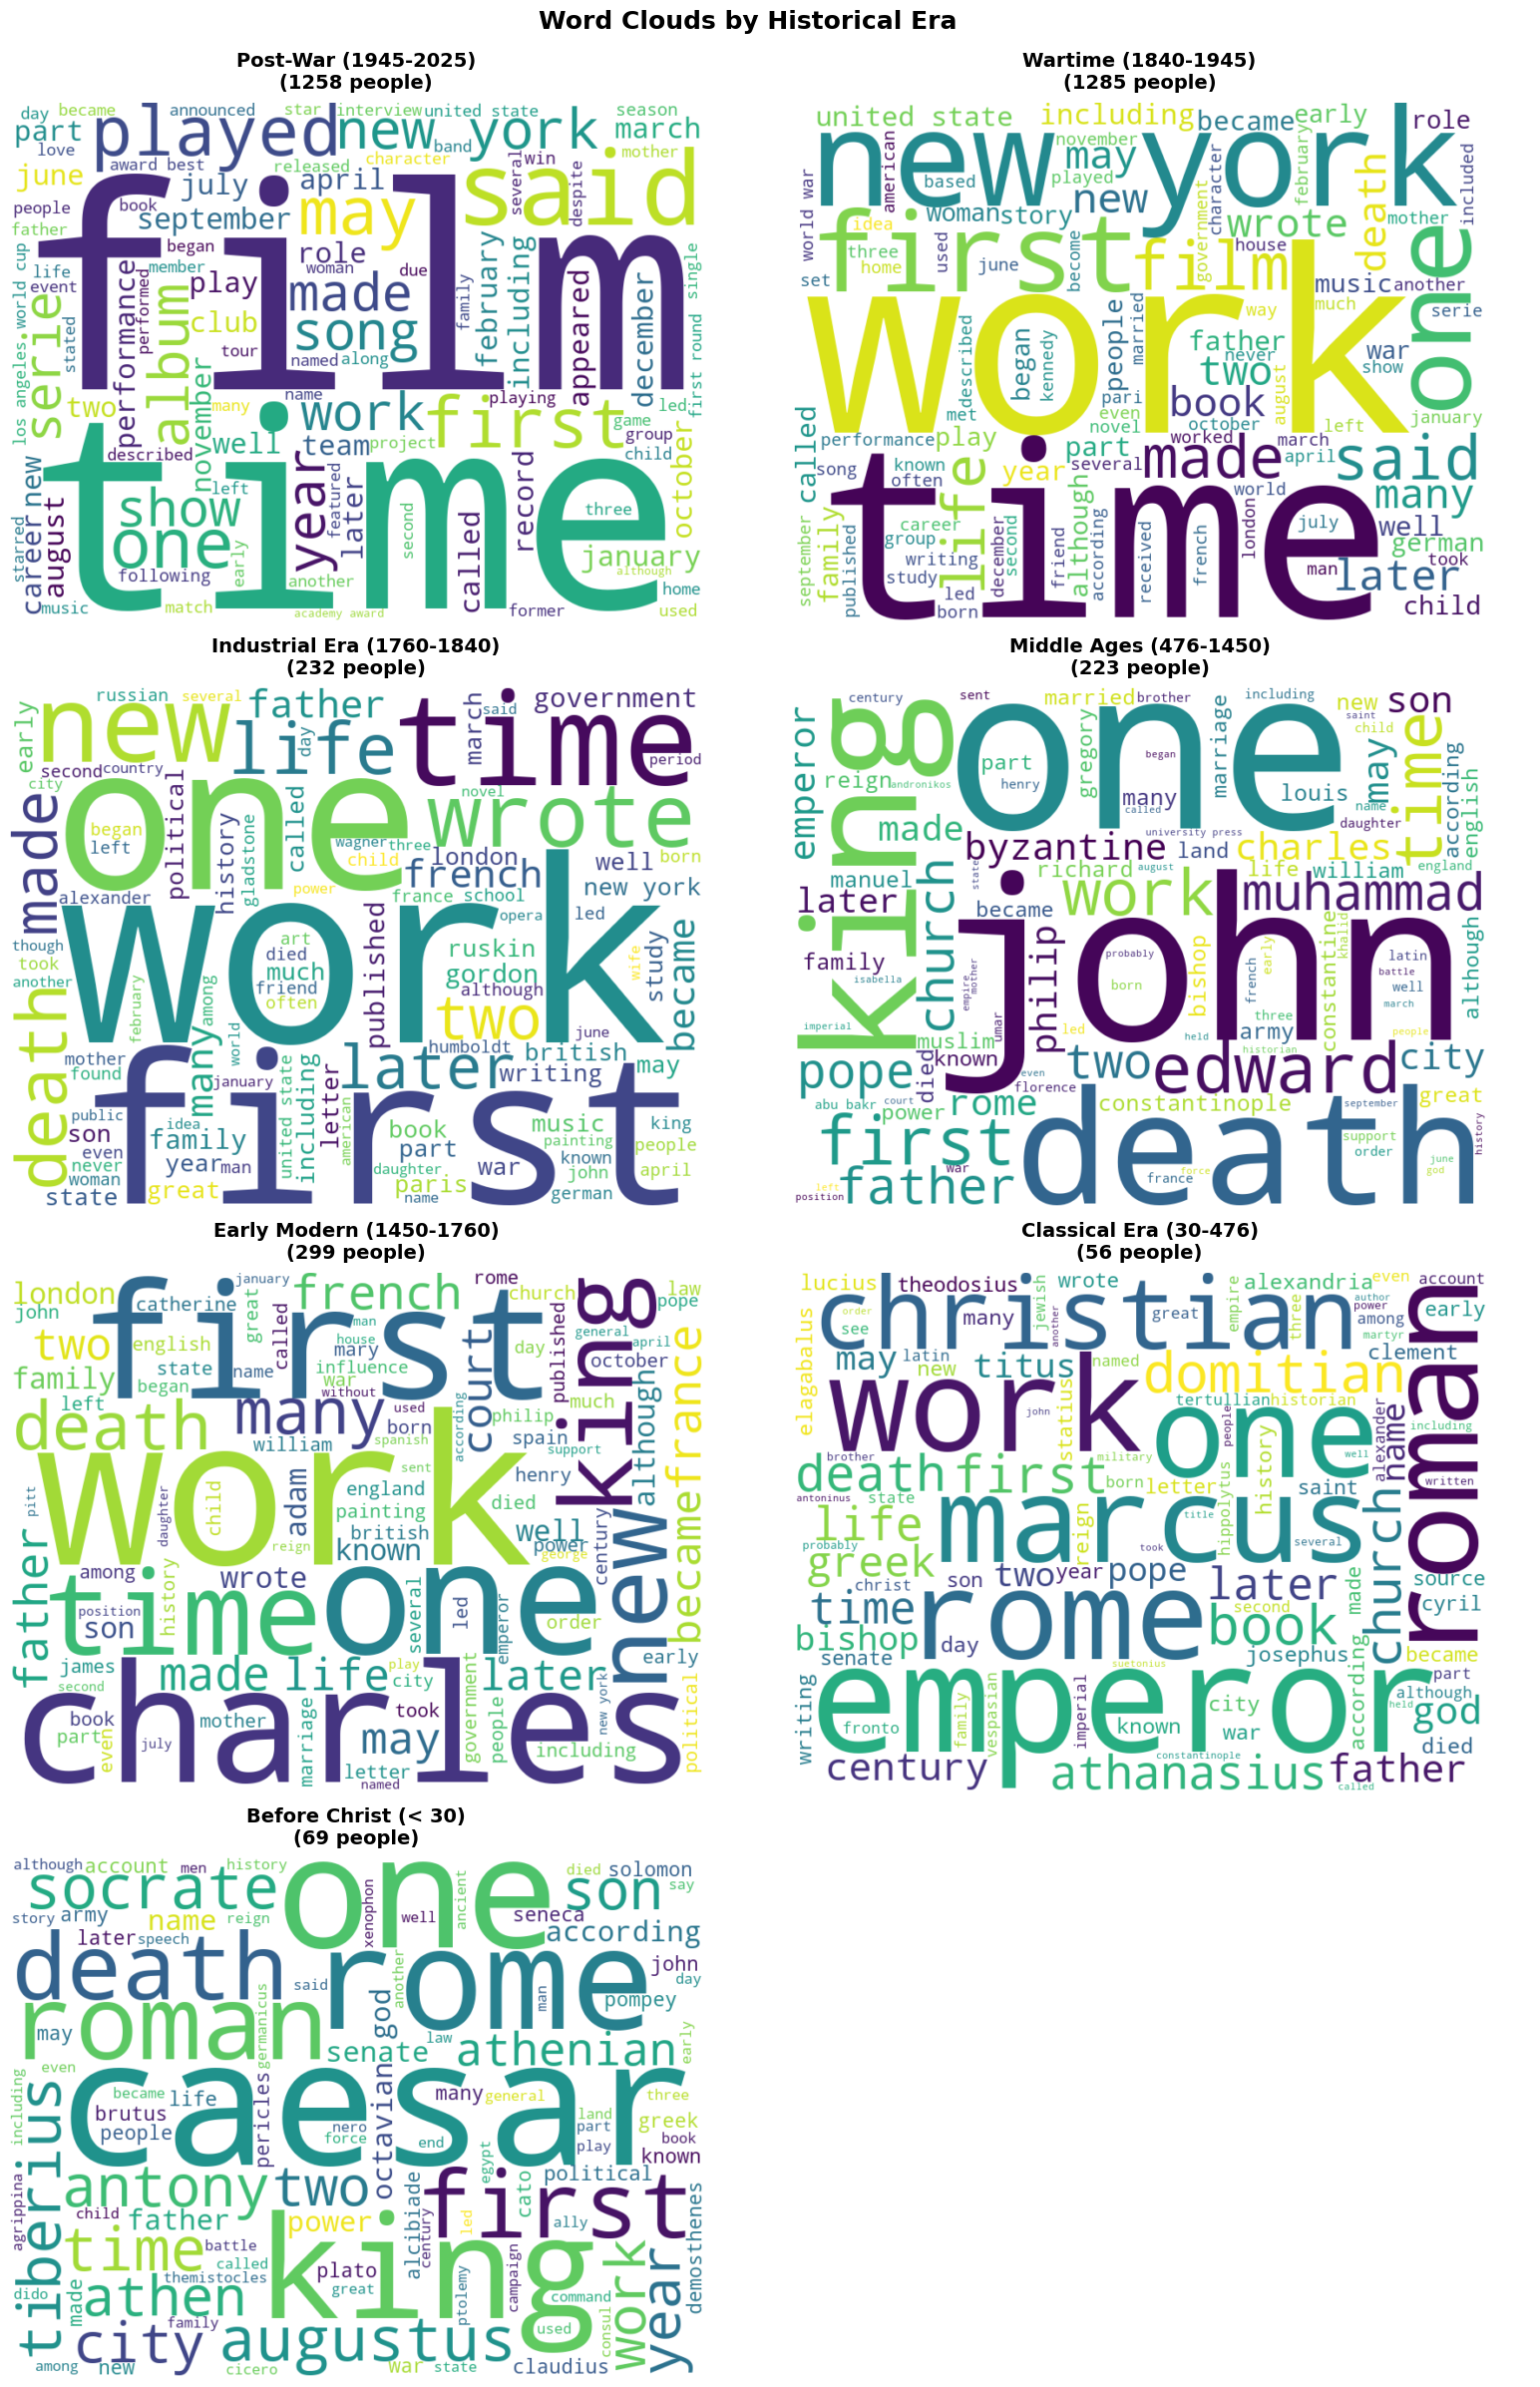


✓ Wordcloud generation complete!


In [7]:
# Filter out Unknown era and eras with very few people
eras_to_process = [(era, people) for era, people in era_groups.items() 
                   if era != 'Unknown' and len(people) >= 5]

print(f"Processing {len(eras_to_process)} eras with sufficient data...\n")

# Calculate subplot layout
n_eras = len(eras_to_process)
n_cols = 2
n_rows = (n_eras + n_cols - 1) // n_cols

# Create figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 6*n_rows))
if n_eras == 1:
    axes = np.array([axes])
axes = axes.flatten()

# Generate wordcloud for each era
for idx, (era, era_people) in enumerate(eras_to_process):
    print(f"{'='*80}")
    print(f"Processing Era {idx+1}/{len(eras_to_process)}: {era}")
    print(f"Number of people: {len(era_people)}")
    print(f"{'='*80}")
    
    # Get combined Wikipedia content for all people in this era
    combined_content = get_combined_content(era_people, network)
    
    if combined_content:
        # Clean and tokenize the content
        tokens = clean_tokenize_lemmatize_nltk(combined_content)
        
        # Create text from tokens
        text = ' '.join(tokens)
        
        if len(text) > 0:
            # Generate wordcloud
            wordcloud = WordCloud(
                width=800, 
                height=600, 
                background_color='white',
                colormap='viridis',
                max_words=100,
                relative_scaling=0.5,
                min_font_size=10
            ).generate(text)
            
            # Plot
            ax = axes[idx]
            ax.imshow(wordcloud, interpolation='bilinear')
            ax.set_title(f'{era}\n({len(era_people)} people)', 
                       fontsize=14, fontweight='bold', pad=10)
            ax.axis('off')
            
            print(f"✓ Wordcloud generated successfully!")
            print(f"  Total tokens: {len(tokens)}")
            print(f"  Unique words: {len(set(tokens))}\n")
        else:
            axes[idx].text(0.5, 0.5, 'No text data available', 
                         ha='center', va='center', fontsize=14)
            axes[idx].set_title(f'{era}\n({len(era_people)} people)', 
                              fontsize=14, fontweight='bold')
            axes[idx].axis('off')
            print(f"✗ No text data available\n")
    else:
        axes[idx].text(0.5, 0.5, 'No Wikipedia content found', 
                     ha='center', va='center', fontsize=14)
        axes[idx].set_title(f'{era}\n({len(era_people)} people)', 
                          fontsize=14, fontweight='bold')
        axes[idx].axis('off')
        print(f"✗ No Wikipedia content found\n")

# Hide unused subplots
for idx in range(len(eras_to_process), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Word Clouds by Historical Era', fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("✓ Wordcloud generation complete!")
print("="*80)

## Analysis Summary

The wordclouds reveal interesting patterns across different historical eras:

- **Classical and Ancient Eras**: Dominated by political, philosophical, and religious terms
- **Middle Ages**: Religious and feudal terminology
- **Early Modern**: Exploration, science, and artistic movements
- **Industrial Era**: Work, technology, and industrial terms
- **Wartime**: Military, political, and conflict-related language
- **Post-War**: Entertainment, sports, film, and modern cultural references

These patterns reflect the dominant themes and concerns of influential people from each era.